Github: https://github.com/mproszewska/B-XAIC <br />
Paper: https://arxiv.org/abs/2505.22252 <br />
Datensatz: https://huggingface.co/datasets/mproszewska/B-XAIC/tree/main <br />

## Imports

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.utils.data import Subset, WeightedRandomSampler
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import Sequential, GCN, GAT, GIN, global_add_pool
from torch_geometric.utils import to_networkx

from rdkit.Chem import BondType
from rdkit import Chem

from tqdm import tqdm

from shapiq.graph import GraphExplainer
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

import random

In [2]:
seed = 123

np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Load data from Huggingface

In [3]:
df = pd.read_csv("b-xaic/data.csv")
path_to_local_explamnations_sdf = "b-xaic/explanations.sdf"
print(df.shape)
print(df.columns.tolist())

(50000, 15)
['Unnamed: 0', 'ChEMBL ID', 'smiles', 'rings-count', 'rings-max', 'X', 'P', 'B', 'indole', 'PAINS', 'split_0', 'split_1', 'split_2', 'split_3', 'split_4']


In [4]:
# aus https://github.com/mproszewska/B-XAIC/blob/main/dataset.py
TASKS = ["B", "P", "X", "indole", "PAINS", "rings-count", "rings-max"]
SYMBOLS = ["C", "N", "O", "F", "Cl", "Br", "P", "S", "B", "I", "Unk"]
# Mapping: Task-Name => Property-Name für die explanations.sdf
TASK_TO_PROP = {
    "B":           "B",
    "P":           "P",
    "X":           "X",
    "indole":      "indole",
    "PAINS":       "pains",
    "rings-count": "rings",
    "rings-max":   "largest_rings",
}

| Was muss das GNN lernen? | Anforderung | Schwierigkeit |
| :--- | :--- | :--- |
| Bor (B)| einzelnes Atom finden | sehr leicht |
| Phosphor (P) | einzelnes Atom finden | sehr leicht |
| Halogene (X) | eines von mehreren Atomen finden | leicht |
| Indol (I)| konkrete Struktur erkennen | mittel |
| PAINS | viele komplexe Strukturen erkennen | schwer |
| rings-count | The model should predict if a molecule contains more than four rings. | sehr schwer |
| rings-max | Detecting large rings with more than six atoms. | sehr schwer |

In [5]:
print(f"Dataset: {len(df):,} molecules, {df['smiles'].nunique():,} unique SMILES")
print(f"Avg. atoms per molecule (proxy via SMILES length): {df['smiles'].str.len().mean():.1f} chars\n")

print("Task label distribution (% positiv))") # wie auf S.5 im paper
for task in TASKS:
    bar = "█" * int(df[task].mean() * 30)
    print(f"  {task:12s} {df[task].mean():5.1%}  {bar}")

print(f"\nSplit (split_0):")
print(df["split_0"].value_counts().to_string())

Dataset: 50,000 molecules, 50,000 unique SMILES
Avg. atoms per molecule (proxy via SMILES length): 66.9 chars

Task label distribution (% positiv))
  B             2.2%  
  P            13.2%  ███
  X            55.9%  ████████████████
  indole       36.8%  ███████████
  PAINS        32.9%  █████████
  rings-count  30.1%  █████████
  rings-max     5.7%  █

Split (split_0):
split_0
train    40000
valid     5000
test      5000


Helper functions:

In [6]:
def atom_label(atom):
    sym = atom.GetSymbol()
    return SYMBOLS.index(sym) if sym in SYMBOLS else len(SYMBOLS) - 1

def bond_type_to_int(bond_type):
    if bond_type == BondType.SINGLE:   return 0
    elif bond_type == BondType.DOUBLE: return 1
    elif bond_type == BondType.TRIPLE: return 2
    elif bond_type == BondType.AROMATIC: return 3
    else: return -1

def smiles_to_graph(mol):
    x = F.one_hot(
        torch.tensor([atom_label(atom) for atom in mol.GetAtoms()], dtype=torch.long),
        len(SYMBOLS),
    ).float()

    row, col, edge_labels = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        row += [i, j]
        col += [j, i]
        edge_type = bond_type_to_int(bond.GetBondType())
        edge_labels += [edge_type, edge_type]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    edge_attr  = torch.tensor(edge_labels, dtype=torch.long).view(-1, 1)
    return x, edge_index, edge_attr

### Configurable Task to explain
Only works if there are training files for the specific task

In [7]:
TASK = "rings-count"

In [8]:
property = TASK_TO_PROP[TASK]

splits = df[[f"split_{i}" for i in range(5)]]
ys     = torch.tensor(df[TASK].tolist()).unsqueeze(1)

dataset = []
skipped = 0

avg_density = 0
avg_size = 0

with Chem.SDMolSupplier(path_to_local_explamnations_sdf, sanitize=False) as suppl:
    for y, mol in tqdm(zip(ys, suppl), total=len(ys)):
        if mol is None:
            skipped += 1
            continue

        x, edge_index, edge_attr = smiles_to_graph(mol)

        p = mol.GetProp(property)
        expl_node_mask = torch.zeros(len(x), dtype=torch.bool)
        if p != "":
            nodes = torch.tensor([int(n) for n in p.split(",")], dtype=torch.long)
            expl_node_mask[nodes] = True

        if property not in ["B", "P", "X"]:
            p = mol.GetProp(f"{property}_edge")
            expl_edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
            if p != "":
                edges = {(int(e1), int(e2)) for e1, e2 in [e.split("#") for e in p.split(",")]}
                for i in range(edge_index.shape[1]):
                    e1, e2 = edge_index[0, i].item(), edge_index[1, i].item()
                    expl_edge_mask[i] = (e1, e2) in edges or (e2, e1) in edges
        else:
            expl_edge_mask = None
        
        graph = Data(
            x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
            expl_node_mask=expl_node_mask, expl_edge_mask=expl_edge_mask,
        )
        dataset.append(graph)
        density = 2 * graph.num_edges / ((graph.num_nodes-1)*graph.num_nodes)
        avg_density += density/len(ys)
        avg_size += graph.num_nodes/len(ys)


print(f"Total number of graphs : {len(dataset)}")
print(f"Average Graph Density of Dataset : {avg_density:.2f}")
print(f"Average Node Size of Dataset : {avg_size:.2f}")

100%|██████████| 50000/50000 [00:33<00:00, 1514.62it/s]

Total number of graphs : 50000
Average Graph Density of Dataset : 0.16
Average Node Size of Dataset : 34.56


In [9]:
#Splits und DataLoader aus dataset.py(get_splits), (train_model.py) 
SPLIT = 0
BATCH = 64

idx = torch.arange(len(splits))
split_col = splits[f"split_{SPLIT}"]
train_idx = idx[split_col == "train"]
val_idx   = idx[split_col == "valid"]
test_idx  = idx[split_col == "test"]

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)
test_set  = Subset(dataset, test_idx)

y_train        = torch.cat([dataset[i].y for i in train_idx])
class_counts   = torch.bincount(y_train)
sample_weights = (1.0 / class_counts.float())[y_train]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

loader_train_sampler = DataLoader(train_set, batch_size=BATCH, sampler=sampler)
loader_train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
loader_val   = DataLoader(val_set,   batch_size=BATCH, shuffle=False)
loader_test  = DataLoader(test_set,  batch_size=BATCH, shuffle=False)

print(f"Task: {TASK}  |  Split: {SPLIT}")
print(f"Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}")

Task: rings-count  |  Split: 0
Train: 40000  Val: 5000  Test: 5000


## GCN, GAT, GIN definition

In [10]:
def get_model(model_type, num_node_features, num_classes,
              hidden_dim=32, num_layers=3, linear_dim=32):

    if model_type == "GCN":
        model = Sequential("x, edge_index, batch", [
            (GCN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    elif model_type == "GAT":
        model = Sequential("x, edge_index, batch", [
            (GAT(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim,
                 act="elu", dropout=0.6),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    elif model_type == "GIN":
        model = Sequential("x, edge_index, batch", [
            (GIN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim,
                 norm="batch_norm"),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    return model

## Explainations

Plotting function for explanations.

In [11]:
def explanation_graph_plot_native(
    interaction_values,
    edge_index: torch.Tensor,
    atom_labels: list,
    num_nodes: int,
    pos: dict,
    ax: plt.Axes = None,
    interaction_threshold: float = 0.15, 
    plot_order: int = 0
):
    if ax is None:
        ax = plt.gca()

    area_scale = 40.0 / max(num_nodes, 1)
    linear_scale = np.sqrt(area_scale)

    physical_linewidth = max(0.5, 1.5 * linear_scale)
    label_fontsize = max(5, int(12 * linear_scale)) 
    
    base_glow_width = physical_linewidth * 2.5
    max_glow_width = physical_linewidth * 10.0 

    base_node_size = 750 * area_scale
    max_halo_area = base_node_size * 2.5 

    node_values = {}
    edge_values = {}
    hyper_edge_values = {}
    
    max_val = 1e-9  

    for subset, value in zip(interaction_values.interaction_lookup.keys(), interaction_values.values):
        if len(subset) == 0:
            continue
            
        if plot_order != 0 and len(subset) > plot_order:
            continue
            
        val = float(value)
        max_val = max(max_val, abs(val))
        
        if len(subset) == 1:
            node_values[subset[0]] = val
        elif len(subset) == 2:
            u, v = subset
            edge_values[tuple(sorted([u, v]))] = val
        elif len(subset) >= 3:
            hyper_edge_values[tuple(sorted(subset))] = val

    cmap = mpl.colormaps['coolwarm']
    norm = mcolors.TwoSlopeNorm(vmin=-max_val, vcenter=0, vmax=max_val)

    physical_edges = set()
    edge_index_np = edge_index.cpu().numpy()
    for i in range(edge_index_np.shape[1]):
        u, v = sorted([int(edge_index_np[0, i]), int(edge_index_np[1, i])])
        if u != v: 
            physical_edges.add((u, v))

    if len(hyper_edge_values) > 0:
        for subset, val in hyper_edge_values.items():
            if abs(val) >= (max_val * interaction_threshold) and abs(val) >= 1e-6:
                val_clipped = np.clip(val, -max_val, max_val) 
                color = cmap(norm(val_clipped))
                
                cx = sum(pos[n][0] for n in subset) / len(subset)
                cy = sum(pos[n][1] for n in subset) / len(subset)
                
                int_width = base_glow_width + (max_glow_width - base_glow_width) * (abs(val_clipped) / max_val)
                
                for n in subset:
                    ax.plot([pos[n][0], cx], [pos[n][1], cy], 
                            color=color, linewidth=int_width * 0.4, linestyle='-', alpha=0.5, zorder=-1)

    if len(edge_values) > 0:
        for edge_key, val in edge_values.items():
            if edge_key in physical_edges:
                continue
                
            if abs(val) >= (max_val * interaction_threshold) and abs(val) >= 1e-6:
                u, v = edge_key
                val_clipped = np.clip(val, -max_val, max_val) 
                color = cmap(norm(val_clipped))
                
                int_width = base_glow_width + (max_glow_width - base_glow_width) * (abs(val_clipped) / max_val)
                
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                        color=color, linewidth=int_width * 0.4, linestyle='-', alpha=0.7, zorder=0)

    for edge_key in physical_edges:
        u, v = edge_key
        val = edge_values.get(edge_key, 0.0)
        
        val_clipped = np.clip(val, -max_val, max_val) 
        color = cmap(norm(val_clipped))
        
        if abs(val) >= 1e-6:
            glow_width = base_glow_width + (max_glow_width - base_glow_width) * (abs(val_clipped) / max_val)
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                    color=color, linewidth=glow_width, linestyle='-', alpha=0.75, zorder=1)

        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                color='black', linewidth=physical_linewidth, linestyle='-', zorder=2)

    node_x = [pos[n][0] for n in range(num_nodes)]
    node_y = [pos[n][1] for n in range(num_nodes)]
    node_vals = [node_values.get(n, 0.0) for n in range(num_nodes)]
    node_vals_clipped = [np.clip(v, -max_val, max_val) for v in node_vals]
    
    halo_colors = [cmap(norm(v)) for v in node_vals_clipped]
    halo_sizes = [
        base_node_size + (max_halo_area - base_node_size) * (abs(v) / max_val) 
        for v in node_vals_clipped
    ]
    ax.scatter(node_x, node_y, s=halo_sizes, c=halo_colors, edgecolors='none', alpha=0.85, zorder=3)

    ax.scatter(node_x, node_y, s=base_node_size, c='white', edgecolors='black', linewidths=physical_linewidth, zorder=4)
    
    for n in range(num_nodes):
        ax.text(pos[n][0], pos[n][1], str(atom_labels[n]), 
                fontsize=label_fontsize, fontweight='bold', color='black',
                ha='center', va='center', zorder=5)

    ax.axis('off')
    ax.margins(x=0.2, y=0.2)
    ax.set_aspect('equal')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_ticks([-max_val, 0, max_val])
    cbar.set_ticklabels([f"{-max_val:.1f}", "0", f"{max_val:.1f}"], fontsize=35)


def decode_atoms(feature_matrix: torch.Tensor):
    SYMBOLS = ["C", "N", "O", "F", "Cl", "Br", "P", "S", "B", "I", "Unk"]
    labels = []
    atom_indices = torch.argmax(feature_matrix, dim=1).cpu().numpy()
    
    for idx in atom_indices:
        if int(idx) < len(SYMBOLS):
            labels.append(SYMBOLS[int(idx)])
        else:
            labels.append('?')
    return labels

Get 4 Different Graphs: two small ones, two large ones. Each of the two either dense or sparse.

In [12]:
all_graphs = dataset
loader = DataLoader(all_graphs, batch_size=1, shuffle=True)
graph_dense_small = None
graph_sparse_small = None
graph_dense_large = None
graph_sparse_large = None

for graph in loader:
    graph = graph.to(device)
    density = 2 * graph.num_edges / ((graph.num_nodes-1)*graph.num_nodes)
    if graph.num_nodes < avg_size:
        if density > avg_density and graph_dense_small is None:
            graph_dense_small = graph
            continue
        elif density < avg_density and graph_sparse_small is None:
            graph_sparse_small = graph
            continue
    elif graph.num_nodes > avg_size:
        if density > avg_density*0.75 and graph_dense_large is None:
            graph_dense_large = graph
            continue
        elif density < avg_density and graph_sparse_large is None:
            graph_sparse_large = graph
            continue
    
    if None not in (graph_dense_small, graph_sparse_small, graph_dense_large, graph_sparse_large):
        break

if None in (graph_dense_small, graph_sparse_small, graph_dense_large, graph_sparse_large):
    print("Warning: The dataset exhausted before finding all 4 specific graph types.")
    print(f"Missing -> Dense Small: {graph_dense_small is None}, Sparse Small: {graph_sparse_small is None}")
    print(f"Missing -> Dense Large: {graph_dense_large is None}, Sparse Large: {graph_sparse_large is None}")

### Configurable
MODEL: GCN, GAT, GIN
NUM_LAYERS = 1,2 or 3


In [44]:
MODEL = "GAT"
NUM_LAYERS = 3

In [45]:
print("Loading Model...")
model = get_model(MODEL, 11, 2, hidden_dim=64, num_layers=NUM_LAYERS)
checkpoint = torch.load(f"models/b-xaic/{TASK}/best_{MODEL.lower()}_{NUM_LAYERS}_layered_b-xaic_{TASK}.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["state_dict"], strict=True)
model.eval()
model.num_layers = NUM_LAYERS

Loading Model...


For each of the 4 preloaded graphs, calculate the explanations and plot them.

Graph: 22 Nodes
Model prediction: 0
Computing Interactions...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/15104 [00:00<?, ? coalition/s]

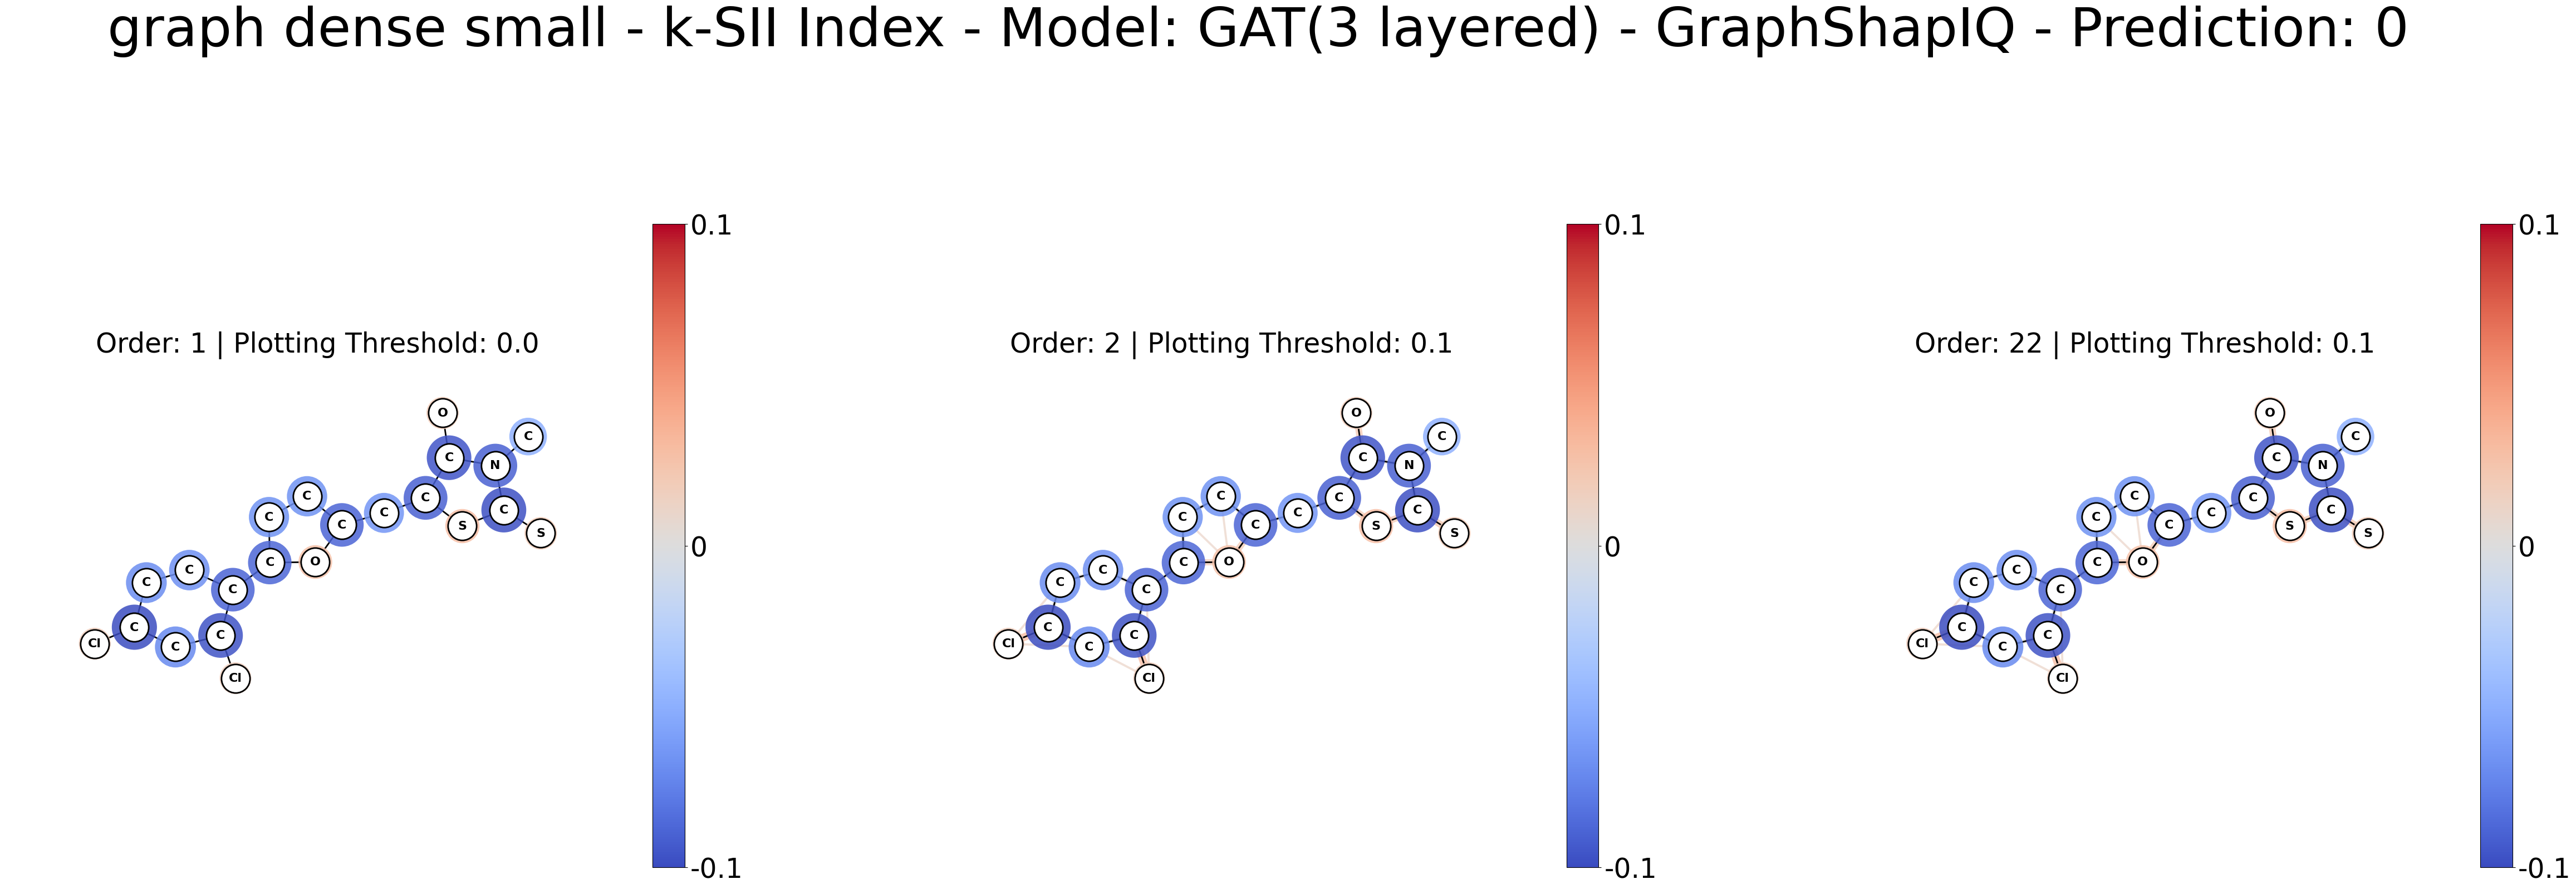

Graph: 34 Nodes
Model prediction: 1
Computing Interactions...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/94976 [00:00<?, ? coalition/s]

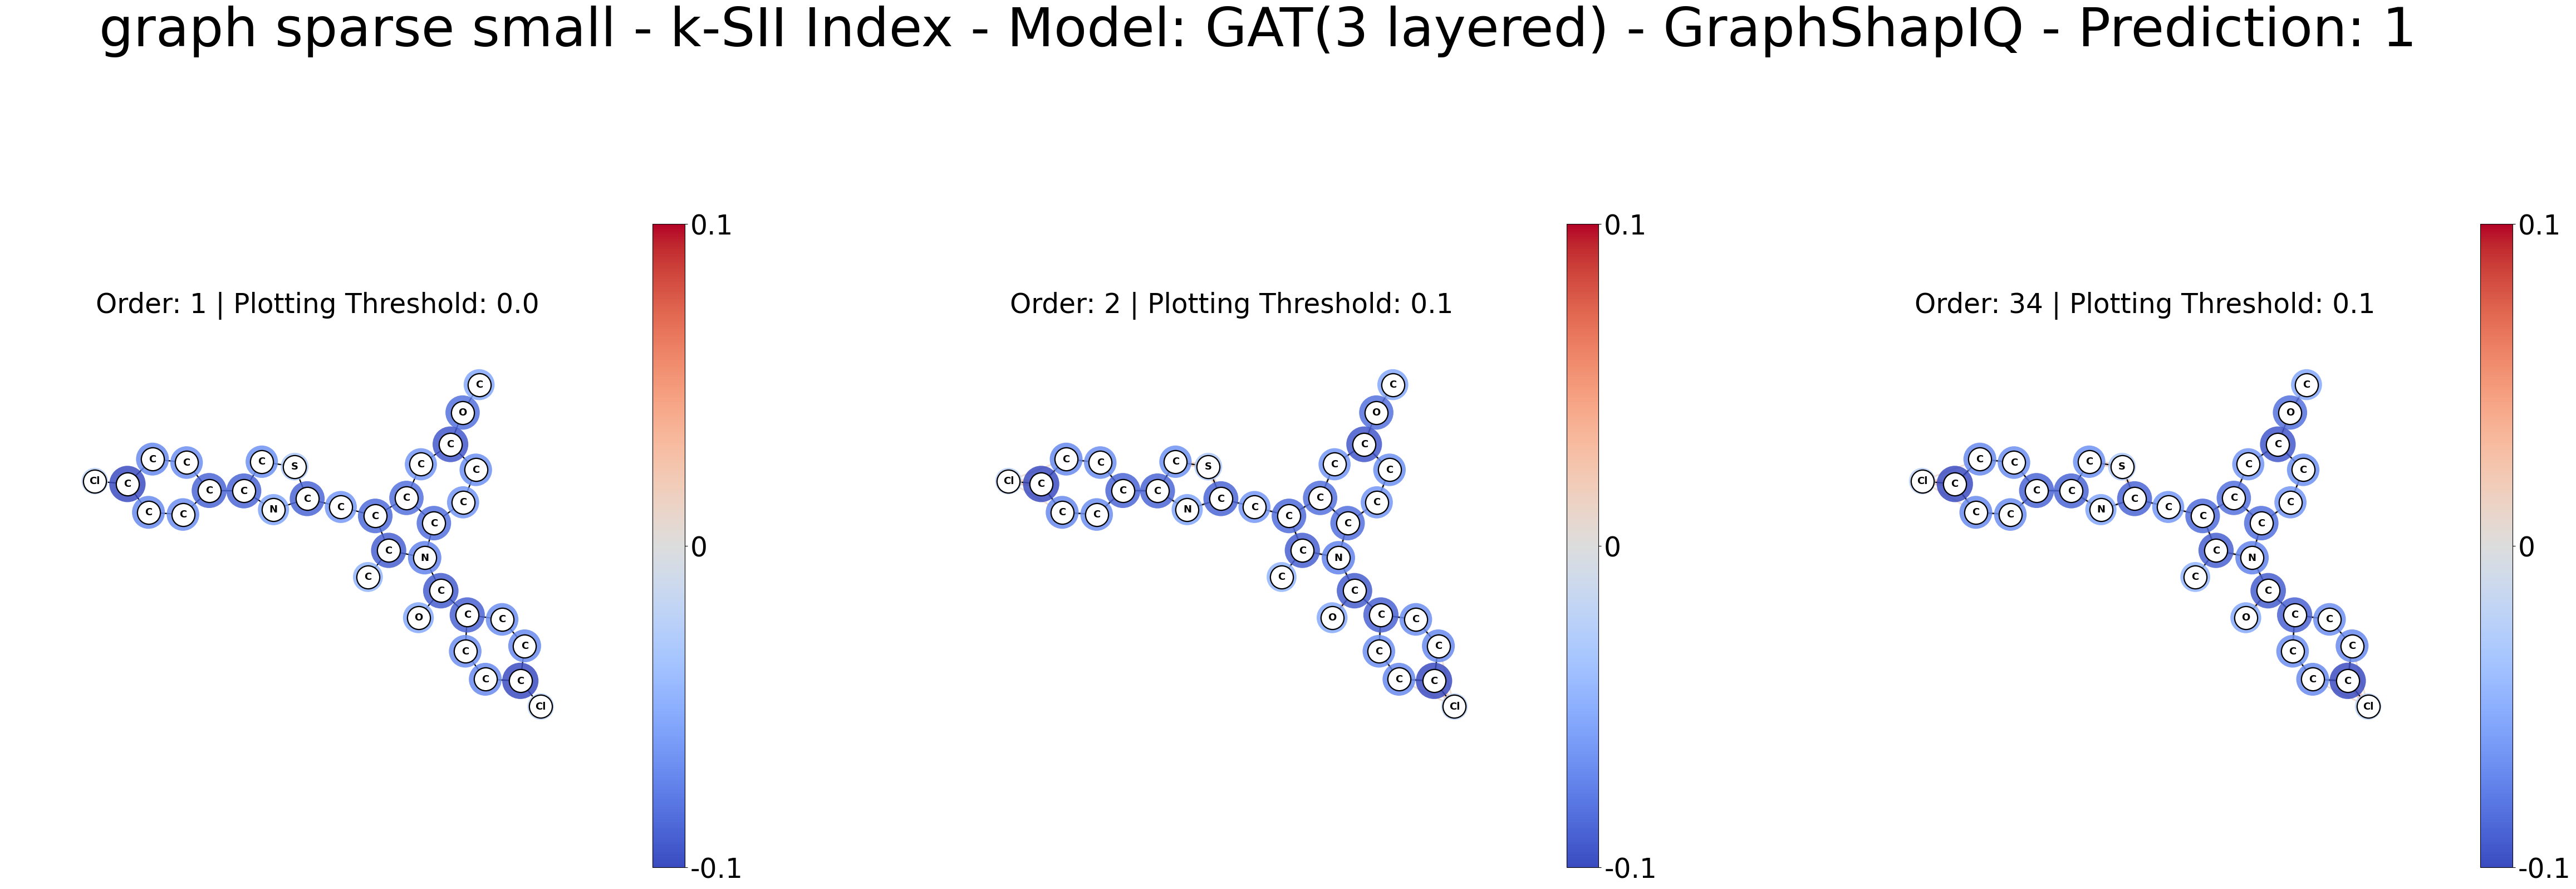

Graph: 36 Nodes
Model prediction: 1
Computing Interactions...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/45312 [00:00<?, ? coalition/s]

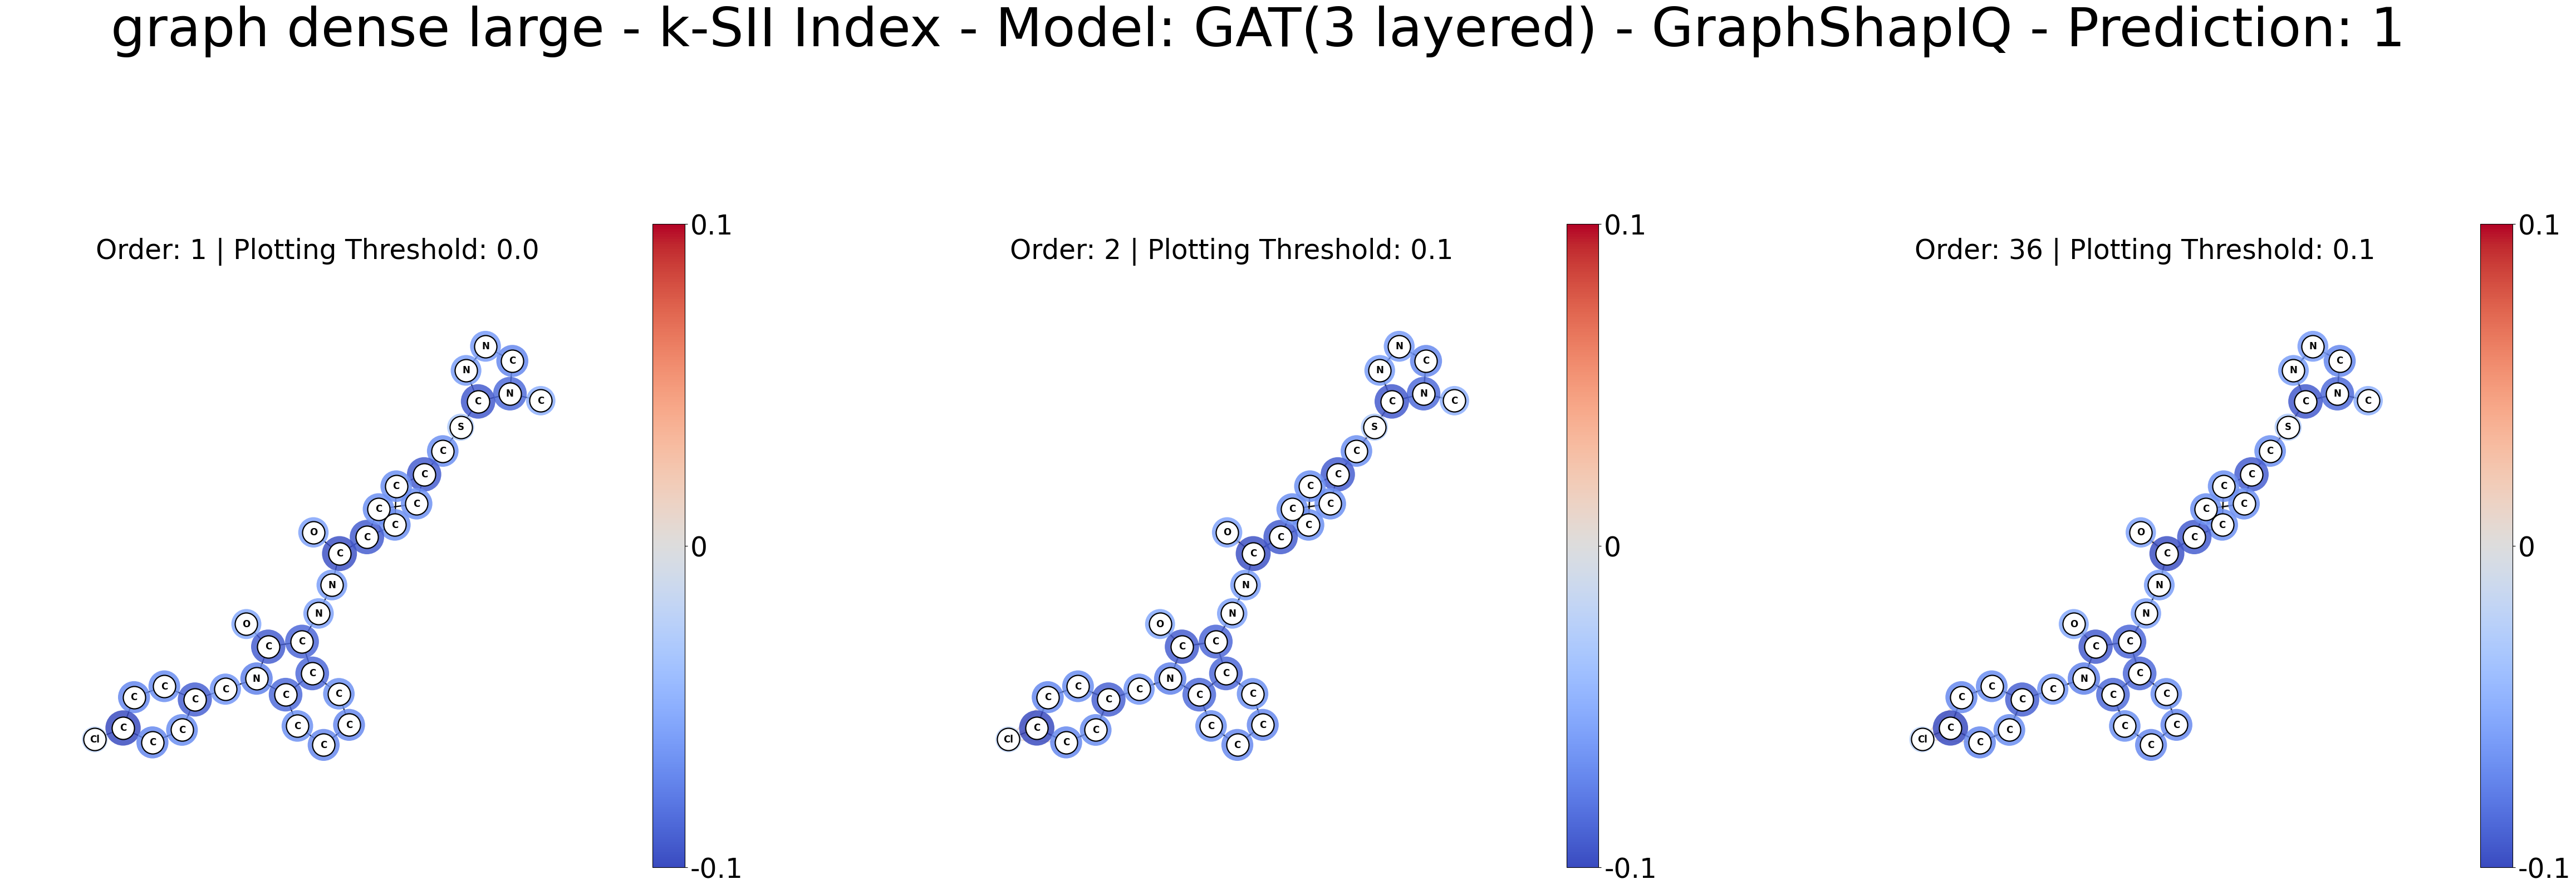

Graph: 45 Nodes
Model prediction: 1
Computing Interactions...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/49920 [00:00<?, ? coalition/s]

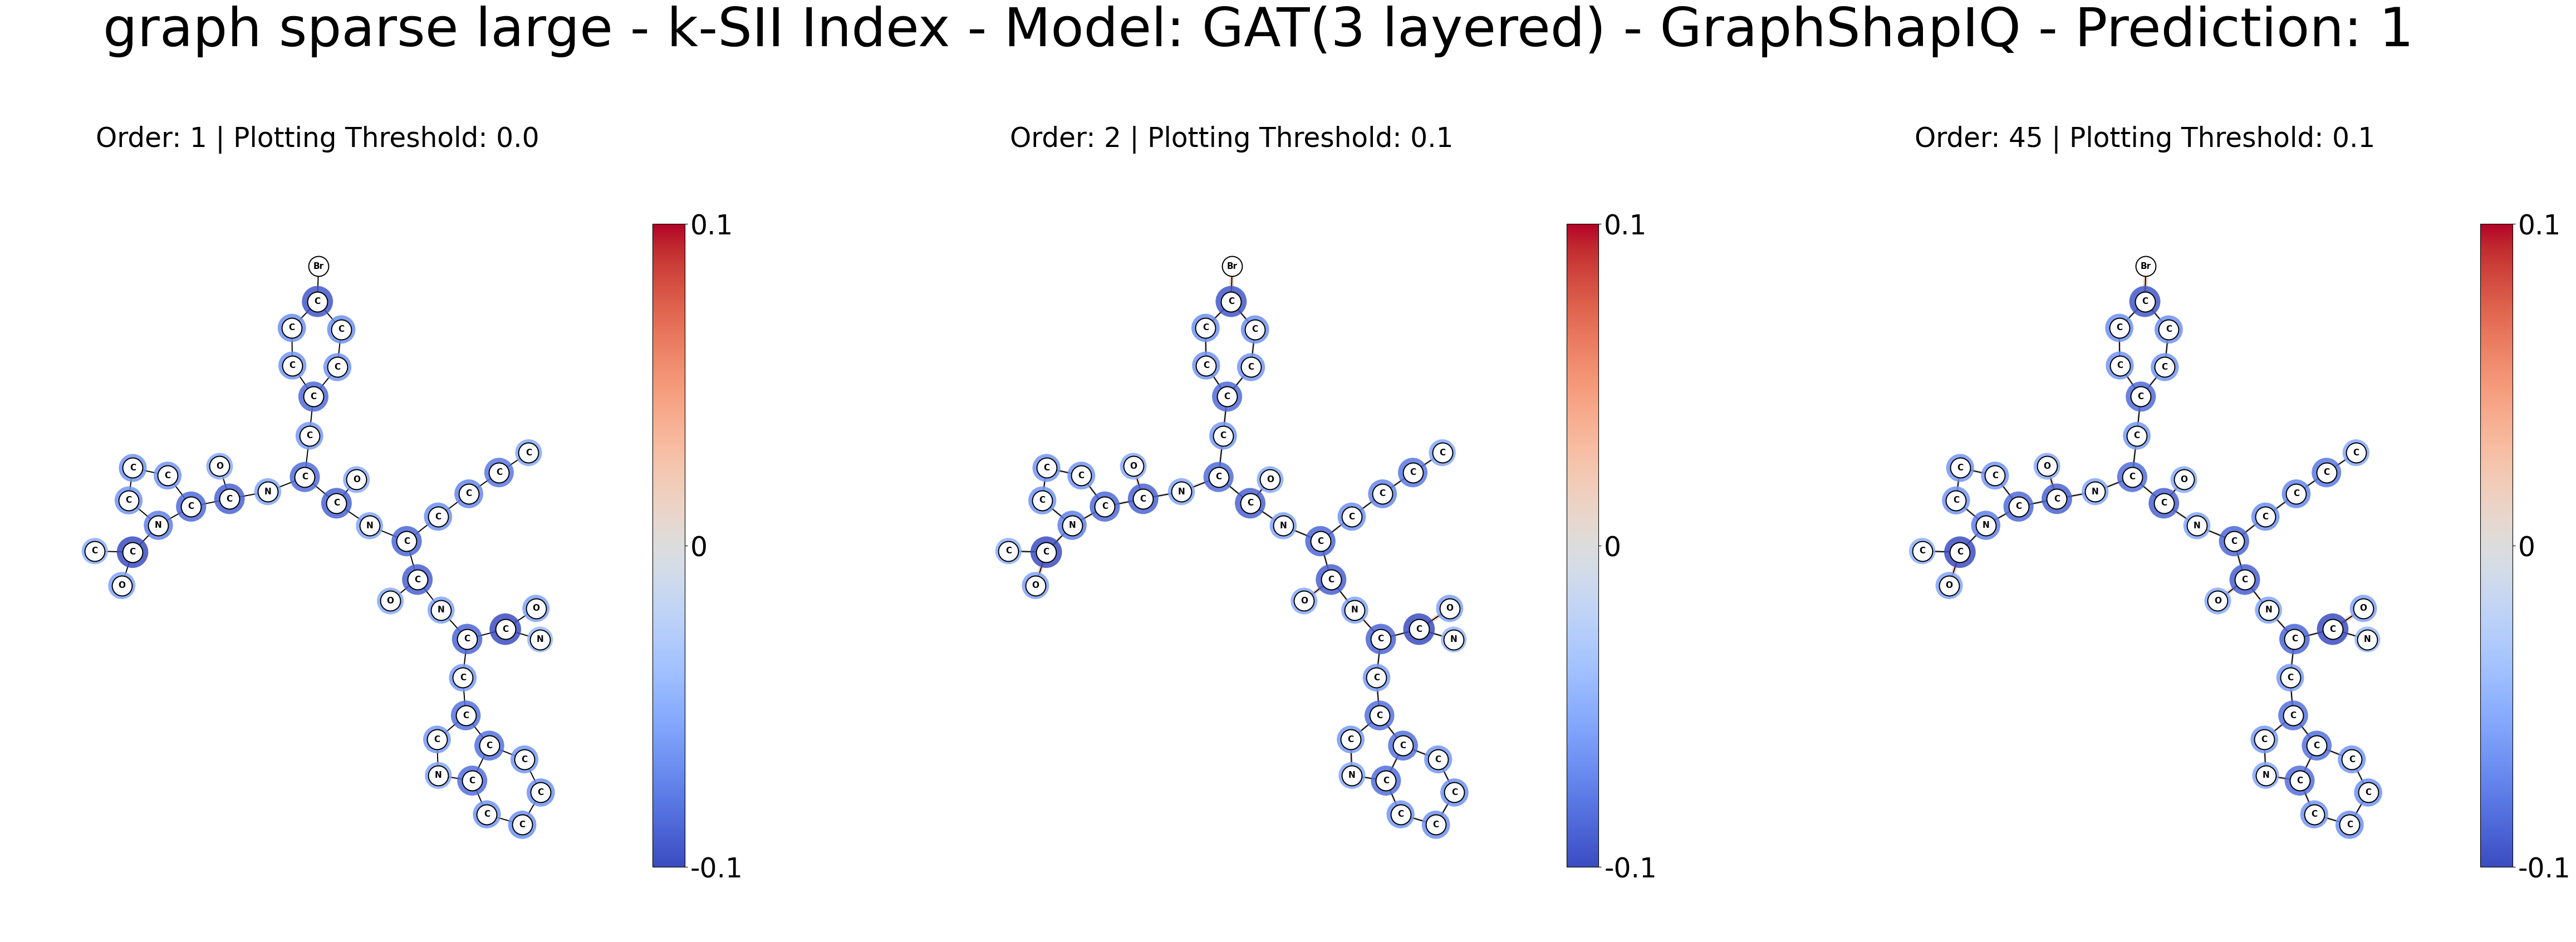

In [ ]:
for g, n in zip([graph_dense_small, graph_sparse_small, graph_dense_large, graph_sparse_large], ["graph_dense_small", "graph_sparse_small", "graph_dense_large", "graph_sparse_large"]):
    x_graph = g
    num_nodes = x_graph.num_nodes if hasattr(x_graph, 'num_nodes') else x_graph.x.shape[0]
    nx_graph = to_networkx(x_graph, to_undirected=True)
    pos = nx.kamada_kawai_layout(nx_graph)
    print(f"Graph: {num_nodes} Nodes")
    atom_labels = decode_atoms(x_graph.x)

    with torch.no_grad():
        out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
        pred = int(out.argmax(dim=1)[0].item())
    print(f"Model prediction: {pred}")

    max_order = x_graph.num_nodes
    l_shapley = True

    explainer = GraphExplainer(model, baseline_strategy='zeros', l_shapley_max_budget=500000, max_order=NUM_LAYERS, verbose=True)
    print("Computing Interactions...")
    interaction_values = explainer.explain(x_graph, max_interaction_size=NUM_LAYERS, max_subset_size=max_order, l_shapley=l_shapley, efiiciency_routine=False, verbose=True)

    fig, axes = plt.subplots(1, 3, figsize=(60, 20))
    fig.suptitle(f"{n.replace("_", " ")} - k-SII Index - Model: {MODEL}({NUM_LAYERS} layered) - {"LShapley" if l_shapley else "GraphShapIQ"} - Prediction: {pred}", fontsize=70)

    for ax, order, threshold in zip(axes, [1, 2, max_order], [0.0, 0.1, 0.1]):
        explanation_graph_plot_native(
            interaction_values=interaction_values, 
            edge_index=x_graph.edge_index, 
            atom_labels=atom_labels,
            num_nodes=num_nodes,
            pos=pos, 
            ax=ax,
            interaction_threshold=threshold,
            plot_order=order
        )
        
        ax.set_title(f"Order: {order} | Plotting Threshold: {threshold}", fontsize=35, pad=10)

    output_file = f"results/plots/{TASK}/{"l_shapley" if l_shapley else "graph_shapiq"}_b-xaic_{NUM_LAYERS}_layered_{MODEL}_on_{n}_explanations_combined.png"
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Graph: 674 Nodes
Model prediction: 1
Computing Interactions...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/5170 [00:00<?, ? coalition/s]

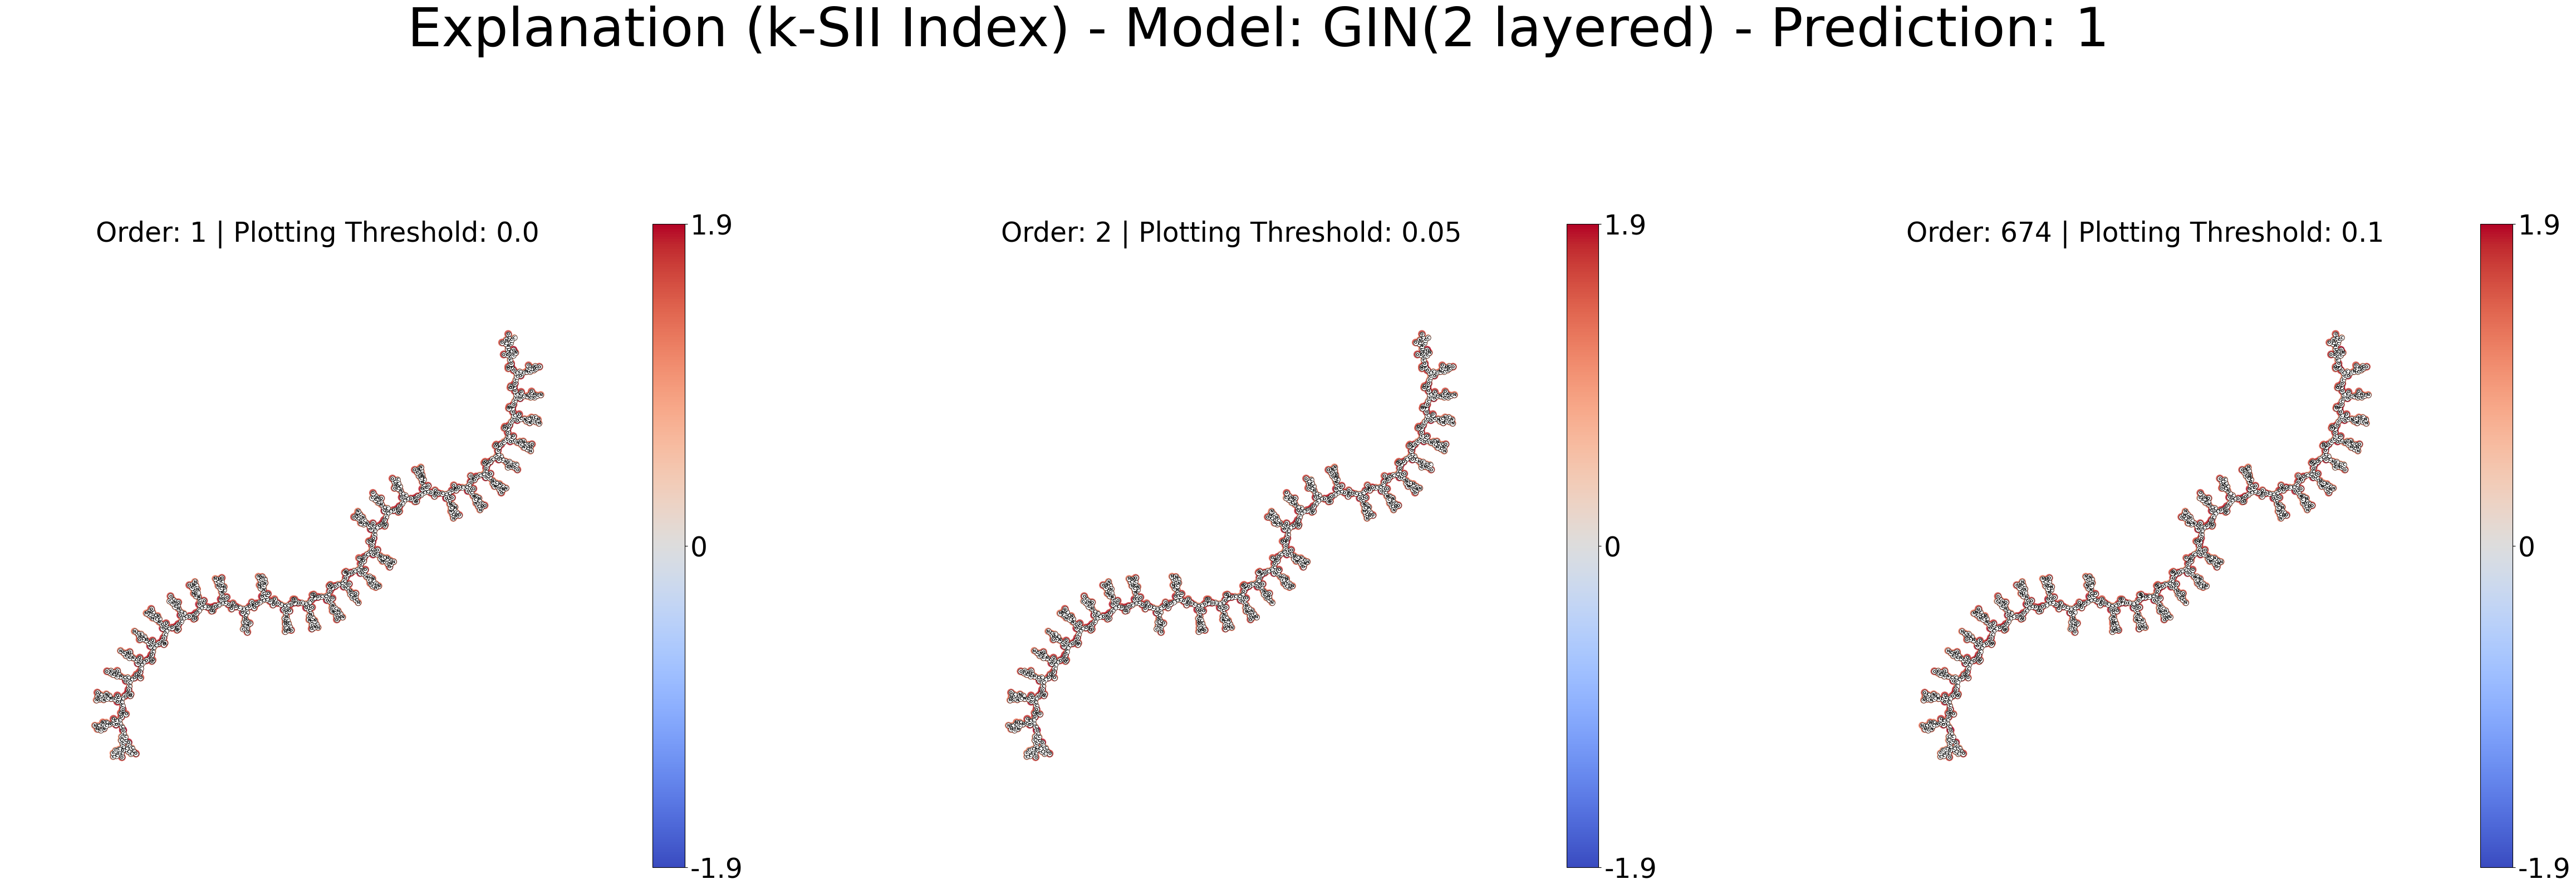

In [17]:
all_graphs = dataset
loader = DataLoader(all_graphs, batch_size=1, shuffle=False)

largest_graph = next(iter(loader))
largest_graph_size = largest_graph.num_nodes

for graph in loader:
    graph = graph.to(device)
    if graph.num_nodes > largest_graph_size:
        largest_graph= graph
        largest_graph_size = graph.num_nodes

x_graph = largest_graph
num_nodes = x_graph.num_nodes if hasattr(x_graph, 'num_nodes') else x_graph.x.shape[0]
nx_graph = to_networkx(x_graph, to_undirected=True)
pos = nx.kamada_kawai_layout(nx_graph)
print(f"Graph: {num_nodes} Nodes")
atom_labels = decode_atoms(x_graph.x)

with torch.no_grad():
    out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
    pred = int(out.argmax(dim=1)[0].item())
print(f"Model prediction: {pred}")

max_order = x_graph.num_nodes
l_shapley = True

explainer = GraphExplainer(model, baseline_strategy='zeros', l_shapley_max_budget=500000, max_order=NUM_LAYERS, verbose=True)
print("Computing Interactions...")
interaction_values = explainer.explain(x_graph, max_interaction_size=NUM_LAYERS, max_subset_size=max_order, l_shapley=l_shapley, efiiciency_routine=False, verbose=True)

fig, axes = plt.subplots(1, 3, figsize=(60, 20))
fig.suptitle(f"Explanation (k-SII Index) - Model: {MODEL}({NUM_LAYERS} layered) - Prediction: {pred}", fontsize=70)

for ax, order, threshold in zip(axes, [1, 2, max_order], [0.0, 0.05, 0.1]):
    explanation_graph_plot_native(
        interaction_values=interaction_values, 
        edge_index=x_graph.edge_index, 
        atom_labels=atom_labels,
        num_nodes=num_nodes,
        pos=pos, 
        ax=ax,
        interaction_threshold=threshold,
        plot_order=order
    )
    
    ax.set_title(f"Order: {order} | Plotting Threshold: {threshold}", fontsize=35, pad=10)

output_file = f"results/plots/b-xaic_{NUM_LAYERS}_layered_{MODEL}_explanation_largest_graph.png"
plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close(fig)

0.1976284584980237
Graph: 38 Nodes
Model prediction: 1
Computing Interactions...


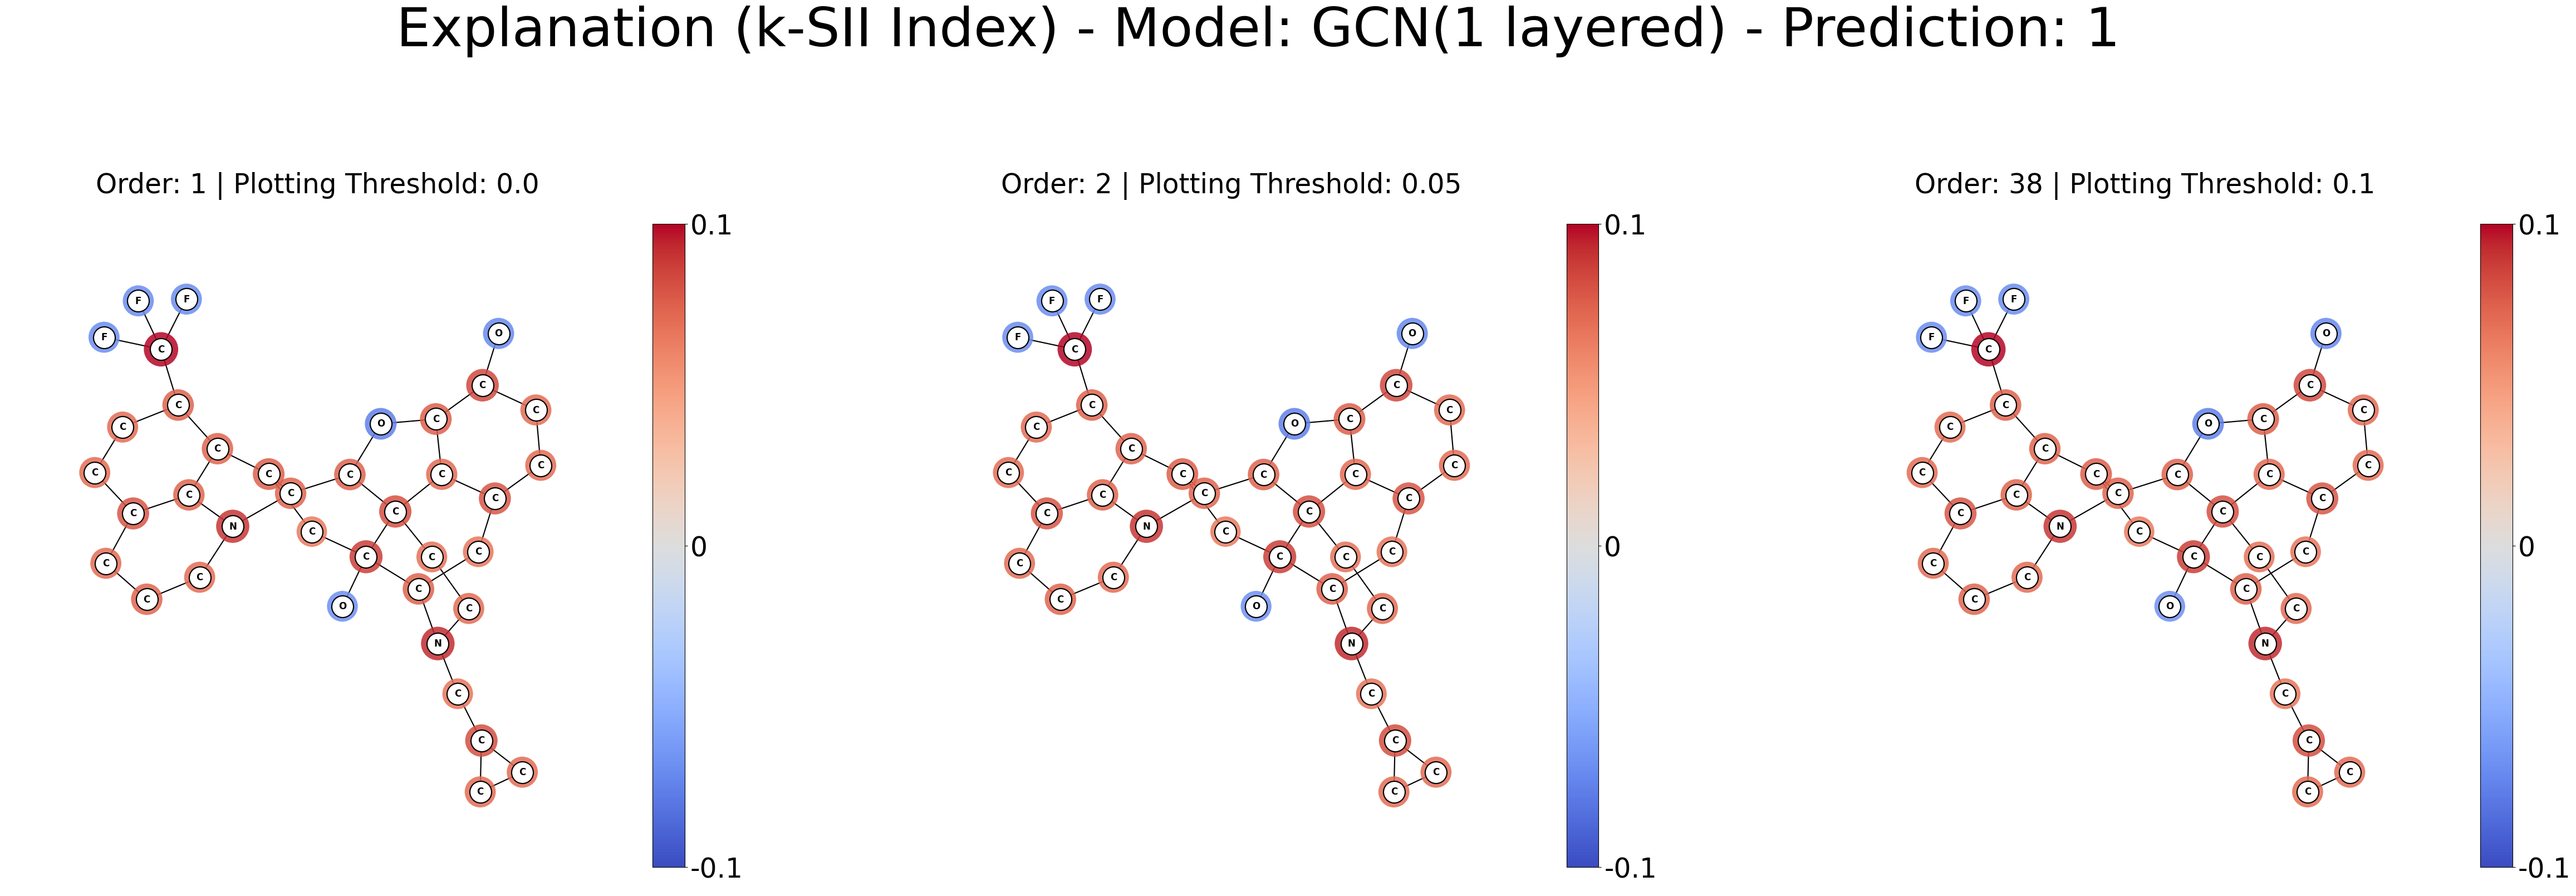

In [ ]:
all_graphs = dataset
loader = DataLoader(all_graphs, batch_size=1, shuffle=False)

most_dense_graph = next(iter(loader))
most_dense_graph_density = density = 2 * most_dense_graph.num_edges / ((most_dense_graph.num_nodes-1)*most_dense_graph.num_nodes)

for graph in loader:
    graph = graph.to(device)
    density = 2 * graph.num_edges / ((graph.num_nodes-1)*graph.num_nodes)
    if density > most_dense_graph_density and graph.num_nodes>37:
        most_dense_graph= graph
        most_dense_graph_density = density

print(density)

x_graph = most_dense_graph
num_nodes = x_graph.num_nodes if hasattr(x_graph, 'num_nodes') else x_graph.x.shape[0]
nx_graph = to_networkx(x_graph, to_undirected=True)
pos = nx.kamada_kawai_layout(nx_graph)
print(f"Graph: {num_nodes} Nodes")
atom_labels = decode_atoms(x_graph.x)

with torch.no_grad():
    out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
    pred = int(out.argmax(dim=1)[0].item())
print(f"Model prediction: {pred}")

max_order = x_graph.num_nodes
l_shapley = True

explainer = GraphExplainer(model, baseline_strategy='zeros', l_shapley_max_budget=500000, max_order=NUM_LAYERS, verbose=True)
print("Computing Interactions...")
interaction_values = explainer.explain(x_graph, max_interaction_size=NUM_LAYERS, max_subset_size=max_order, l_shapley=l_shapley, efiiciency_routine=False, verbose=True)

fig, axes = plt.subplots(1, 3, figsize=(60, 20))
fig.suptitle(f"Explanation (k-SII Index) - Model: {MODEL}({NUM_LAYERS} layered) - Prediction: {pred}", fontsize=70)

for ax, order, threshold in zip(axes, [1, 2, max_order], [0.0, 0.05, 0.1]):
    explanation_graph_plot_native(
        interaction_values=interaction_values, 
        edge_index=x_graph.edge_index, 
        atom_labels=atom_labels,
        num_nodes=num_nodes,
        pos=pos, 
        ax=ax,
        interaction_threshold=threshold,
        plot_order=order
    )
    
    ax.set_title(f"Order: {order} | Plotting Threshold: {threshold}", fontsize=35, pad=10)

output_file = f"results/plots/b-xaic_{NUM_LAYERS}_layered_{MODEL}_explanation_most_dense_graph.png"
plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close(fig)